In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image 
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\zhiho\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


In [3]:
DATA_ROOT = Path(
    r"C:\Users\zhiho\Desktop\AI_stuff\05_Projects\School"
    r"\Computer Vision and Deep Learning - Term Project"
    r"\05_Data"
)

MANIFEST_DIR = DATA_ROOT / "manifests"

TRAIN_CSV = MANIFEST_DIR / "train_classifier.csv"
VAL_CSV = MANIFEST_DIR / "val_classifier.csv"
TEST_CSV = MANIFEST_DIR / "test_classifier.csv"

print("DATA_ROOT:", DATA_ROOT.exists())
print("TRAIN:", TRAIN_CSV.exists())
print("VAL:", VAL_CSV.exists())
print("TEST:", TEST_CSV.exists())

DATA_ROOT: True
TRAIN: True
VAL: True
TEST: True


In [4]:
dtype_map = {
    "source_id": str,
    "generator_source_id": str,
}

train_df = pd.read_csv(TRAIN_CSV, dtype=dtype_map)
val_df = pd.read_csv(VAL_CSV, dtype=dtype_map)
test_df = pd.read_csv(TEST_CSV, dtype=dtype_map)

print(f"Train samples: {len(train_df):,}")
print(f"Val samples:   {len(val_df):,}")
print(f"Test samples:  {len(test_df):,}")

Train samples: 100,000
Val samples:   20,000
Test samples:  20,000


In [6]:
train_df.head()

,source_id,generator_source_id,image_path,label,class_name,payload_rate
0,00001,000002,lsb-run-20260922-233255-728056/clean/000002.png,0,clean,0.000000
1,00001,000002,lsb-run-20260922-233255-728056/stego/000002.png,1,stego,0.459819
2,00003,000004,lsb-run-20260922-233255-728056/clean/000004.png,0,clean,0.000000
3,00003,000004,lsb-run-20260922-233255-728056/stego/000004.png,1,stego,0.250522
4,00004,000005,lsb-run-20260922-233255-728056/clean/000005.png,0,clean,0.000000


In [7]:
train_df.columns.tolist()

['source_id',
 'generator_source_id',
 'image_path',
 'label',
 'class_name',
 'payload_rate']

In [9]:
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print(name)
    print(df["class_name"].value_counts())
    print()

Train
class_name
clean    50000
stego    50000
Name: count, dtype: int64

Validation
class_name
clean    10000
stego    10000
Name: count, dtype: int64

Test
class_name
clean    10000
stego    10000
Name: count, dtype: int64



In [10]:
train_sources = set(train_df["source_id"])
val_sources = set(val_df["source_id"])
test_sources = set(test_df["source_id"])

print("Train ∩ Val:", len(train_sources & val_sources))
print("Train ∩ Test:", len(train_sources & test_sources))
print("Val ∩ Test:", len(val_sources & test_sources))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [13]:
pair_labels = (
    train_df
    .groupby("source_id")["label"]
    .agg(lambda x: set(x))
)

bad_pairs = pair_labels[pair_labels != {0, 1}]

print("Bad pairs:", len(bad_pairs))

Bad pairs: 0


In [14]:
row = train_df.iloc[0]

image_path = DATA_ROOT / row["image_path"]

print("Source ID:", row["source_id"])
print("Class:", row["class_name"])
print("Path:", image_path)
print("Exists:", image_path.exists())

Source ID: 00001
Class: clean
Path: C:\Users\zhiho\Desktop\AI_stuff\05_Projects\School\Computer Vision and Deep Learning - Term Project\05_Data\lsb-run-20260922-233255-728056\clean\000002.png
Exists: True


In [15]:
class LSBClassificationDataset(Dataset):
    def __init__(self, dataframe, data_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.data_root / row["image_path"]

        with Image.open(image_path) as img:
            image = img.convert("RGB")

        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [17]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [18]:
train_dataset = LSBClassificationDataset(
    dataframe=train_df,
    data_root=DATA_ROOT,
    transform=basic_transform,
)

val_dataset = LSBClassificationDataset(
    dataframe=val_df,
    data_root=DATA_ROOT,
    transform=basic_transform,
)

test_dataset = LSBClassificationDataset(
    dataframe=test_df,
    data_root=DATA_ROOT,
    transform=basic_transform,
)

In [19]:
print(f"Train: {len(train_dataset):,}")
print(f"Val:   {len(val_dataset):,}")
print(f"Test:  {len(test_dataset):,}")

Train: 100,000
Val:   20,000
Test:  20,000


In [20]:
image_tensor, label = train_dataset[0]

print("Shape:", image_tensor.shape)
print("dtype:", image_tensor.dtype)
print("Min:", image_tensor.min().item())
print("Max:", image_tensor.max().item())
print("Label:", label)

Shape: torch.Size([3, 128, 128])
dtype: torch.float32
Min: 0.0
Max: 1.0
Label: 0


In [21]:
num_workers=0

In [22]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [23]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("First labels:", labels[:20])

Images: torch.Size([64, 3, 128, 128])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
First labels: tensor([1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1])


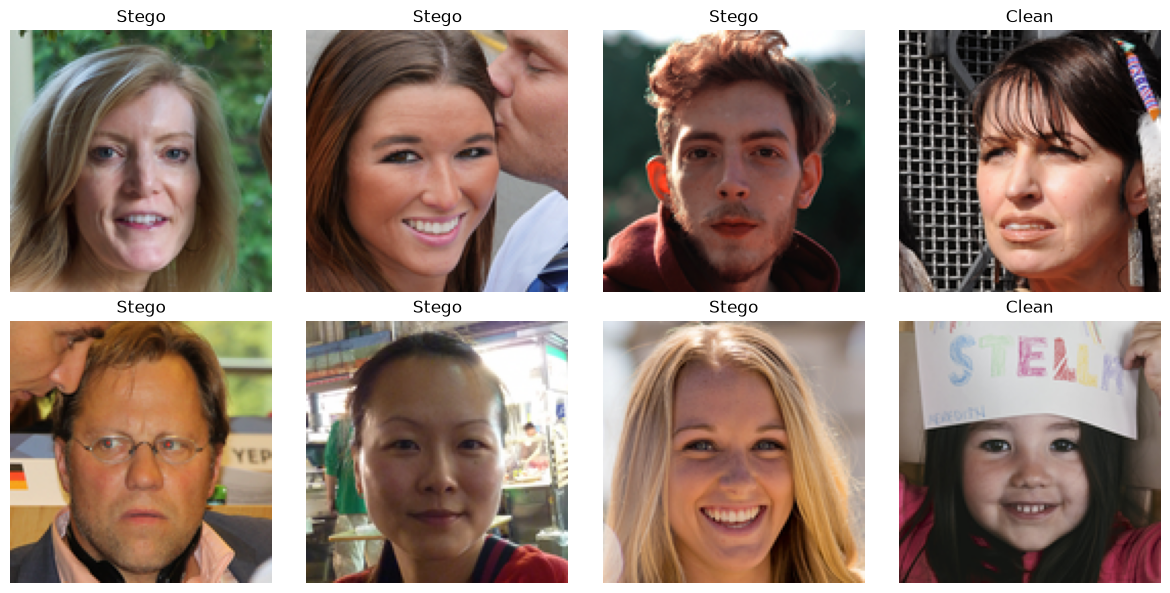